In [2]:
import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\akash\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
import os
os.chdir(r'D:\PERSONAL PROJECTS')
print(os.getcwd())  # confirm it switched

D:\PERSONAL PROJECTS


In [4]:
df = pd.read_csv('labeled_data.csv')
df.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [5]:
df = df[['tweet', 'class']]
df.head()

,tweet,class
0,!!! RT @mayasolovely: As a woman you shouldn't...,2
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,1
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,1
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,1
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,1


In [6]:
df['class'].value_counts()

class
1    19190
2     4163
0     1430
Name: count, dtype: int64

In [7]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'rt\s+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'&\w+;', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    return ' '.join(words)

df['clean_tweet'] = df['tweet'].apply(clean_text)
df[['tweet', 'clean_tweet']].head()

,tweet,clean_tweet
0,!!! RT @mayasolovely: As a woman you shouldn't...,woman shouldnt complain clean hous man alway t...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,boy dat coldtyga dwn bad cuffin dat hoe st place
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,dawg ever fuck bitch stato cri confus shit
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,look like tranni
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,shit hear might true might faker bitch told ya


In [8]:
X = df['clean_tweet']
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(19826,) (4957,)
class
1    15352
2     3330
0     1144
Name: count, dtype: int64
class
1    3838
2     833
0     286
Name: count, dtype: int64


In [9]:
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape, X_test_tfidf.shape)

(19826, 5000) (4957, 5000)


In [10]:
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_tfidf, y_train)

svm_model = LinearSVC(class_weight='balanced', max_iter=5000)
svm_model.fit(X_train_tfidf, y_train)

rf_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_model.fit(X_train_tfidf, y_train)

print("All models trained.")

All models trained.


In [11]:
lr_preds = lr_model.predict(X_test_tfidf)
svm_preds = svm_model.predict(X_test_tfidf)
rf_preds = rf_model.predict(X_test_tfidf)

In [12]:
target_names = ['hate_speech', 'offensive_language', 'neither']

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds, target_names=target_names))

print("=== Linear SVM ===")
print(classification_report(y_test, svm_preds, target_names=target_names))

print("=== Random Forest ===")
print(classification_report(y_test, rf_preds, target_names=target_names))

=== Logistic Regression ===
                    precision    recall  f1-score   support

       hate_speech       0.32      0.64      0.43       286
offensive_language       0.97      0.85      0.91      3838
           neither       0.77      0.95      0.85       833

          accuracy                           0.85      4957
         macro avg       0.69      0.81      0.73      4957
      weighted avg       0.90      0.85      0.87      4957

=== Linear SVM ===
                    precision    recall  f1-score   support

       hate_speech       0.40      0.42      0.41       286
offensive_language       0.94      0.92      0.93      3838
           neither       0.80      0.90      0.85       833

          accuracy                           0.88      4957
         macro avg       0.72      0.74      0.73      4957
      weighted avg       0.89      0.88      0.89      4957

=== Random Forest ===
                    precision    recall  f1-score   support

       hate_speech      

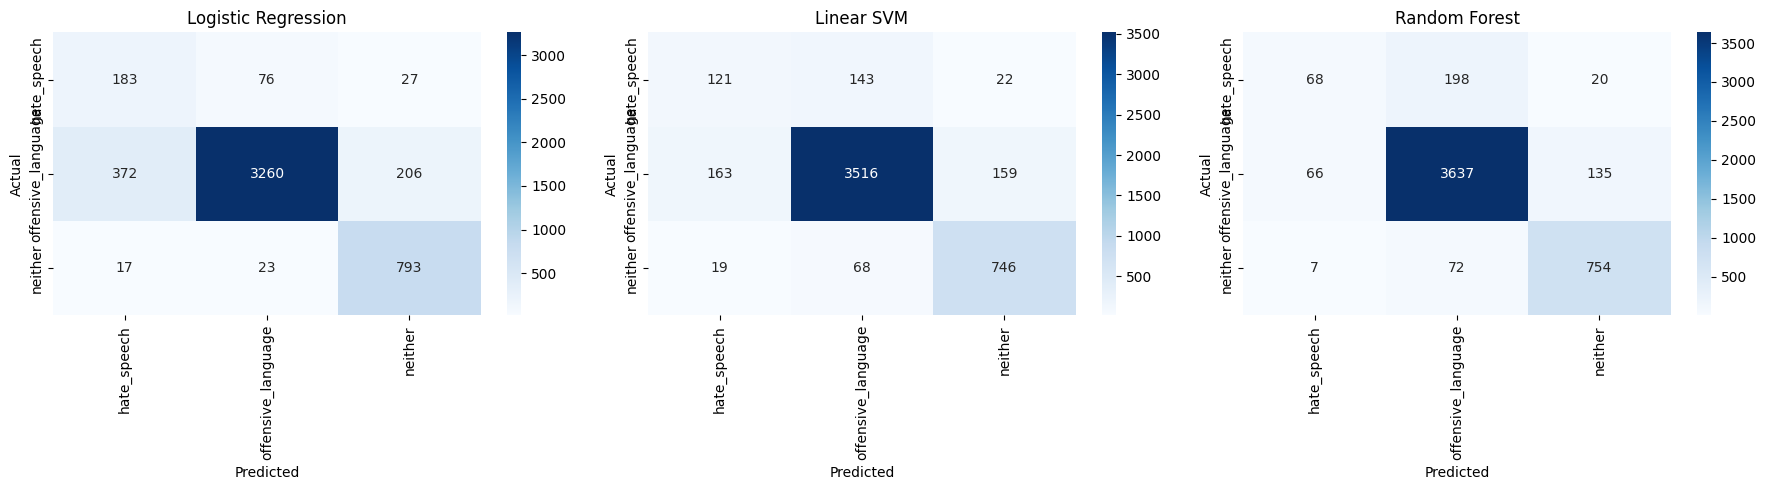

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_preds = [("Logistic Regression", lr_preds), ("Linear SVM", svm_preds), ("Random Forest", rf_preds)]

for ax, (name, preds) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=target_names, yticklabels=target_names)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [14]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_smote).value_counts().to_dict())

Before SMOTE: {1: 15352, 2: 3330, 0: 1144}
After SMOTE: {1: 15352, 2: 15352, 0: 15352}


In [15]:
lr_model_smote = LogisticRegression(max_iter=1000)
lr_model_smote.fit(X_train_smote, y_train_smote)

svm_model_smote = LinearSVC(max_iter=5000)
svm_model_smote.fit(X_train_smote, y_train_smote)

rf_model_smote = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model_smote.fit(X_train_smote, y_train_smote)

print("All SMOTE-trained models trained.")

All SMOTE-trained models trained.


In [16]:
lr_smote_preds = lr_model_smote.predict(X_test_tfidf)
svm_smote_preds = svm_model_smote.predict(X_test_tfidf)
rf_smote_preds = rf_model_smote.predict(X_test_tfidf)

print("=== Logistic Regression (SMOTE) ===")
print(classification_report(y_test, lr_smote_preds, target_names=target_names))

print("=== Linear SVM (SMOTE) ===")
print(classification_report(y_test, svm_smote_preds, target_names=target_names))

print("=== Random Forest (SMOTE) ===")
print(classification_report(y_test, rf_smote_preds, target_names=target_names))

=== Logistic Regression (SMOTE) ===
                    precision    recall  f1-score   support

       hate_speech       0.32      0.58      0.41       286
offensive_language       0.96      0.87      0.91      3838
           neither       0.80      0.91      0.85       833

          accuracy                           0.86      4957
         macro avg       0.69      0.79      0.73      4957
      weighted avg       0.90      0.86      0.87      4957

=== Linear SVM (SMOTE) ===
                    precision    recall  f1-score   support

       hate_speech       0.26      0.48      0.34       286
offensive_language       0.94      0.87      0.91      3838
           neither       0.81      0.87      0.84       833

          accuracy                           0.85      4957
         macro avg       0.67      0.74      0.70      4957
      weighted avg       0.88      0.85      0.86      4957

=== Random Forest (SMOTE) ===
                    precision    recall  f1-score   support



In [17]:
lr_probs = lr_model.predict_proba(X_test_tfidf)
print(lr_probs.shape)
print(lr_probs[:5])

(4957, 3)
[[0.54140292 0.38021551 0.07838157]
 [0.00416769 0.01884358 0.97698873]
 [0.4734424  0.51706268 0.00949492]
 [0.07059015 0.92718407 0.00222578]
 [0.22816874 0.73607847 0.03575279]]


In [18]:
def predict_with_threshold(probs, hate_threshold):
    preds = []
    for p in probs:
        if p[0] >= hate_threshold:
            preds.append(0)
        else:
            preds.append(np.argmax(p[1:]) + 1)
    return np.array(preds)

custom_preds = predict_with_threshold(lr_probs, hate_threshold=0.3)
print(classification_report(y_test, custom_preds, target_names=target_names))

                    precision    recall  f1-score   support

       hate_speech       0.22      0.71      0.34       286
offensive_language       0.97      0.78      0.87      3838
           neither       0.79      0.93      0.85       833

          accuracy                           0.80      4957
         macro avg       0.66      0.81      0.69      4957
      weighted avg       0.90      0.80      0.83      4957



In [19]:
thresholds = [0.2, 0.25, 0.3, 0.35, 0.4]

for t in thresholds:
    preds = predict_with_threshold(lr_probs, hate_threshold=t)
    p = precision_score(y_test, preds, labels=[0], average='macro')
    r = recall_score(y_test, preds, labels=[0], average='macro')
    f1 = f1_score(y_test, preds, labels=[0], average='macro')
    print(f"Threshold: {t} | hate_speech Precision: {p:.3f} | Recall: {r:.3f} | F1: {f1:.3f}")

Threshold: 0.2 | hate_speech Precision: 0.167 | Recall: 0.794 | F1: 0.275
Threshold: 0.25 | hate_speech Precision: 0.196 | Recall: 0.759 | F1: 0.312
Threshold: 0.3 | hate_speech Precision: 0.225 | Recall: 0.713 | F1: 0.342
Threshold: 0.35 | hate_speech Precision: 0.253 | Recall: 0.682 | F1: 0.369
Threshold: 0.4 | hate_speech Precision: 0.275 | Recall: 0.643 | F1: 0.385


In [20]:
tfidf_char = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), max_features=10000)

X_train_char = tfidf_char.fit_transform(X_train)
X_test_char = tfidf_char.transform(X_test)

print(X_train_char.shape, X_test_char.shape)

(19826, 10000) (4957, 10000)


In [21]:
lr_char_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_char_model.fit(X_train_char, y_train)

lr_char_preds = lr_char_model.predict(X_test_char)

print("=== Logistic Regression (char n-grams) ===")
print(classification_report(y_test, lr_char_preds, target_names=target_names))

=== Logistic Regression (char n-grams) ===
                    precision    recall  f1-score   support

       hate_speech       0.28      0.64      0.39       286
offensive_language       0.97      0.83      0.90      3838
           neither       0.77      0.95      0.85       833

          accuracy                           0.84      4957
         macro avg       0.67      0.81      0.71      4957
      weighted avg       0.90      0.84      0.86      4957



In [22]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: False


In [23]:
import joblib

joblib.dump(lr_model, 'hate_speech_model.pkl')
joblib.dump(tfidf, 'hate_speech_tfidf.pkl')

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.


In [24]:
custom_weights = {0: 10, 1: 1, 2: 2}

lr_custom_model = LogisticRegression(max_iter=1000, class_weight=custom_weights)
lr_custom_model.fit(X_train_tfidf, y_train)

lr_custom_preds = lr_custom_model.predict(X_test_tfidf)

print("=== Logistic Regression (custom weights) ===")
print(classification_report(y_test, lr_custom_preds, target_names=target_names))

=== Logistic Regression (custom weights) ===
                    precision    recall  f1-score   support

       hate_speech       0.33      0.57      0.42       286
offensive_language       0.95      0.89      0.92      3838
           neither       0.83      0.89      0.86       833

          accuracy                           0.87      4957
         macro avg       0.71      0.78      0.73      4957
      weighted avg       0.90      0.87      0.88      4957



In [25]:
import joblib

joblib.dump(lr_model, 'hate_speech_model.pkl')
joblib.dump(tfidf, 'hate_speech_tfidf.pkl')

print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.


In [26]:
import gradio as gr

def gradio_predict(message):
    cleaned = clean_text(message)
    vectorized = tfidf.transform([cleaned])
    probs = lr_model.predict_proba(vectorized)[0]
    
    return {
        "Hate Speech": float(probs[0]),
        "Offensive Language": float(probs[1]),
        "Neither": float(probs[2])
    }

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(lines=3, placeholder="Enter a message to check...", label="Message"),
    outputs=gr.Label(num_top_classes=3, label="Prediction"),
    title="Hate Speech Detector",
    description="Enter a message to classify it as Hate Speech, Offensive Language, or Neither. Powered by a Logistic Regression model with TF-IDF (1-2 gram) features, trained on the Davidson et al. dataset with balanced class weighting.",
    examples=[
        ["Hey, are we still meeting for lunch tomorrow?"],
        ["You're such an idiot, I can't believe you did that"],
        ["I hate you and everyone like you should disappear"],
        ["Can you send me the notes from today's class?"]
    ],
    flagging_mode="never"
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [27]:
import gensim.downloader as api

glove_model = api.load("glove-twitter-100")

In [28]:
def get_tweet_vector(text, model, vector_size=100):
    words = text.split()
    word_vectors = [model[word] for word in words if word in model]
    
    if len(word_vectors) == 0:
        return np.zeros(vector_size)
    
    return np.mean(word_vectors, axis=0)

In [29]:
X_train_glove = np.array([get_tweet_vector(text, glove_model) for text in X_train])
X_test_glove = np.array([get_tweet_vector(text, glove_model) for text in X_test])

print(X_train_glove.shape, X_test_glove.shape)

(19826, 100) (4957, 100)


In [30]:
lr_glove_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_glove_model.fit(X_train_glove, y_train)

lr_glove_preds = lr_glove_model.predict(X_test_glove)

print("=== Logistic Regression (GloVe embeddings) ===")
print(classification_report(y_test, lr_glove_preds, target_names=target_names))

=== Logistic Regression (GloVe embeddings) ===
                    precision    recall  f1-score   support

       hate_speech       0.19      0.58      0.29       286
offensive_language       0.96      0.75      0.84      3838
           neither       0.66      0.86      0.75       833

          accuracy                           0.76      4957
         macro avg       0.60      0.73      0.63      4957
      weighted avg       0.87      0.76      0.79      4957

